# AutoEncoder on Correlation Matrices
In this notebook we train an AutoEncoder (with non-linear activations) on full correlation matrices, compress them into a latent space, reconstruct them, and evaluate reconstruction quality across different latent dimensions.

In [1]:
from pathlib import Path
import random
import warnings
import sys
import json

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

## Step 1: Load Train/Val/Test Splits
Load correlation matrices from an existing dataset folder containing `train.pt`, `val.pt`, and `test.pt`.
- Local PC: `data/processed/dataset/<DATASET_NAME>`
- Google Colab: `dataset_tesi/<DATASET_NAME>`

In [2]:
DATASET_NAME = 'data_00_20_w724_s10'

if 'google.colab' in sys.modules:
    print('Ambiente rilevato: Google Colab')
    IS_COLAB = True
else:
    print('Ambiente rilevato: Locale (PC)')
    IS_COLAB = False

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    base_dir = Path('/content/drive/MyDrive/dataset_tesi')
else:
    project_root = Path.cwd().resolve().parent
    base_dir = project_root / 'data' / 'processed' / 'dataset'

dataset_dir = base_dir / DATASET_NAME

TRAIN_FILE = dataset_dir / 'train.pt'
VAL_FILE = dataset_dir / 'val.pt'
TEST_FILE = dataset_dir / 'test.pt'

for split_path in (TRAIN_FILE, VAL_FILE, TEST_FILE):
    if not split_path.exists():
        raise FileNotFoundError(
            f"Errore: Il file '{split_path.name}' non e stato trovato in: {dataset_dir.absolute()}"
        )

print(f'Dataset selezionato: {DATASET_NAME}')
print(f'Train: {TRAIN_FILE.name} | Val: {VAL_FILE.name} | Test: {TEST_FILE.name}')

Ambiente rilevato: Locale (PC)
Dataset selezionato: data_00_20_w724_s10
Train: train.pt | Val: val.pt | Test: test.pt


In [3]:
def load_corr_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')

    if isinstance(payload, dict):
        corr_tensor = payload.get('corr_tensor', None)
        meta = {k: v for k, v in payload.items() if k != 'corr_tensor'}
    elif isinstance(payload, torch.Tensor):
        corr_tensor = payload
        meta = {}
    else:
        raise TypeError(f'Unsupported .pt format: {type(payload)}')

    if corr_tensor is None:
        raise KeyError('corr_tensor key not found in .pt file')

    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')

    return corr_tensor.float(), meta


train_corr, train_meta = load_corr_payload(TRAIN_FILE)
val_corr, val_meta = load_corr_payload(VAL_FILE)
test_corr, test_meta = load_corr_payload(TEST_FILE)

if train_corr.shape[1:] != test_corr.shape[1:]:
    raise ValueError(f'Train/test asset dims mismatch: {train_corr.shape} vs {test_corr.shape}')
if val_corr.shape[1:] != train_corr.shape[1:]:
    raise ValueError(f'Val/train asset dims mismatch: {val_corr.shape} vs {train_corr.shape}')

print(f'train_corr shape: {tuple(train_corr.shape)}')
print(f'val_corr shape:   {tuple(val_corr.shape)}')
print(f'test_corr shape:  {tuple(test_corr.shape)}')

train_corr shape: (289, 362, 362)
val_corr shape:   (82, 362, 362)
test_corr shape:  (41, 362, 362)


## Step 2: Prepare Matrices from Existing Splits
Use full correlation matrices as input. Each matrix is flattened to a vector of size `N x N`.
Train/val/test come directly from the loaded split files (no random split in notebook).

In [4]:
train_np = train_corr.numpy().astype(np.float32)
val_np = val_corr.numpy().astype(np.float32)
test_np = test_corr.numpy().astype(np.float32)

n_train, n_assets, _ = train_np.shape
n_val = val_np.shape[0]
n_test = test_np.shape[0]
n_matrices = n_train + n_val + n_test
n_features = n_assets * n_assets

x_train = torch.from_numpy(train_np.reshape(n_train, n_features))
x_val = torch.from_numpy(val_np.reshape(n_val, n_features))
x_test = torch.from_numpy(test_np.reshape(n_test, n_features))

VAL_FRACTION = n_val / n_matrices
TEST_FRACTION = n_test / n_matrices

print(f'Number of matrices: {n_matrices}')
print(f'Matrix shape: ({n_assets}, {n_assets})')
print(f'Flattened input size: {n_features}')
print(f'Train size: {n_train} | Val size: {n_val} | Test size: {n_test}')

Number of matrices: 412
Matrix shape: (362, 362)
Flattened input size: 131044
Train size: 289 | Val size: 82 | Test size: 41


## Step 3: Define an AutoEncoder
- hidden_dims = None -> linear AE
- hidden_dims = [...] -> AE (ReLU + dropout)

In [5]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int, hidden_dims=None, dropout_prob: float = 0.02):
        super().__init__()

        # Se hidden_dims è None, creiamo un Linear AE semplice
        if hidden_dims is None:
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, latent_dim)
            )
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, input_dim)
            )
        else:
            # Caso Deep Autoencoder con Dropout e attivazioni
            dimensions = [input_dim, *hidden_dims, latent_dim]

            # --- ENCODER ---
            encoder_layers = []
            for i in range(len(dimensions) - 1):
                encoder_layers.append(nn.Linear(dimensions[i], dimensions[i + 1]))
                if i < len(dimensions) - 2:
                    encoder_layers.append(nn.ReLU())
                    encoder_layers.append(nn.Dropout(dropout_prob))
            self.encoder = nn.Sequential(*encoder_layers)

            # --- DECODER ---
            decoder_dims = dimensions[::-1]
            decoder_layers = []
            for i in range(len(decoder_dims) - 1):
                decoder_layers.append(nn.Linear(decoder_dims[i], decoder_dims[i + 1]))
                if i < len(decoder_dims) - 2:
                    decoder_layers.append(nn.ReLU())
                    decoder_layers.append(nn.Dropout(dropout_prob))
                else:
                    # Output layer: Tanh è ottima se i dati sono normalizzati tra -1 e 1
                    decoder_layers.append(nn.ReLU())
            self.decoder = nn.Sequential(*decoder_layers)

    def architecture_signature(self):
        return [
            [int(layer.in_features), int(layer.out_features)]
            for layer in self.encoder
            if isinstance(layer, nn.Linear)
        ]

    def forward(self, x: torch.Tensor):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

## Step 4: Training and Evaluation Utilities
Train the model, reconstruct matrices, and compute reconstruction errors.

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_AE(
    x_train_tensor: torch.Tensor,
    x_val_tensor: torch.Tensor,
    latent_dim: int,
    hidden_dims=None,
    epochs: int = 80,
    batch_size: int = 64,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    dropout: float = 0.02,
    seed: int = 42,
    scheduler_name: str = 'none',
    cosine_t_max: int = 80,
    cosine_eta_min: float = 1e-8,
    resume_state_dict=None,
    initial_best_val=None,
    patience: int = 10,  # <-- 1) MODIFICA: Aggiunto parametro di pazienza
):

    # 1) Seed for reproducibility
    set_seed(seed)

    # 2) Model, optimizer, criterion, scheduler
    model = AutoEncoder(input_dim=x_train_tensor.shape[1], latent_dim=latent_dim, hidden_dims=hidden_dims, dropout_prob=dropout).to(device)
    if resume_state_dict is not None:
        model.load_state_dict(resume_state_dict)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    scheduler_key = str(scheduler_name).strip().lower()
    valid_schedulers = {'none', 'cosine'}
    if scheduler_key not in valid_schedulers:
        raise ValueError(f"Invalid scheduler '{scheduler_name}'. Choose one of {sorted(valid_schedulers)}")

    scheduler = None
    if scheduler_key == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=cosine_t_max,
            eta_min=cosine_eta_min,
        )

    # 3) DataLoaders
    train_loader = DataLoader(TensorDataset(x_train_tensor), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(x_val_tensor), batch_size=batch_size, shuffle=False)

    history = {'train_loss': [], 'val_loss': [], 'lr': []}

    # 4) Initialization of best validation loss
    if resume_state_dict is not None:
        if initial_best_val is None:
            model.eval()
            val_loss_sum = 0.0
            with torch.no_grad():
                for (xb,) in val_loader:
                    xb = xb.to(device)
                    pred = model(xb)
                    loss = criterion(pred, xb)
                    val_loss_sum += loss.item() * xb.size(0)
            initial_best_val = val_loss_sum / len(val_loader.dataset)

        best_val = float(initial_best_val)
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        best_val = float('inf')
        best_state = None

    # <-- 2) MODIFICA: Inizializza il contatore per l'early stopping
    patience_counter = 0

    # 5) Training loop
    for epoch in range(epochs):
        model.train()
        train_loss_sum = 0.0
        current_lr = float(optimizer.param_groups[0]['lr'])

        for (xb,) in train_loader:
            xb = xb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, xb)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * xb.size(0)

        train_loss = train_loss_sum / len(train_loader.dataset)

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for (xb,) in val_loader:
                xb = xb.to(device)
                pred = model(xb)
                loss = criterion(pred, xb)
                val_loss_sum += loss.item() * xb.size(0)

        val_loss = val_loss_sum / len(val_loader.dataset)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(current_lr)

        if scheduler is not None:
            if scheduler_key == 'plateau':
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # <-- 3) MODIFICA: Logica di controllo dell'Early Stopping
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0  # Reset se la loss migliora
        else:
            patience_counter += 1 # Incrementa se la loss non migliora

        print(f'Epoch {epoch + 1:>3}/{epochs} | lr={current_lr:.2e} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}')

        # Controllo se abbiamo esaurito la pazienza
        if patience_counter >= patience:
            print(f" Early stopping attivato all'epoca {epoch + 1}. La val_loss non migliora da {patience} epoche.")
            break  # Esci dal ciclo for

    # 6) Load best state and return
    if best_state is None:
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)

    return model, history, best_val

def reconstruct_matrices(model: nn.Module, x_tensor: torch.Tensor, n_assets: int, batch_size: int = 4):
    model.eval()
    loader = DataLoader(TensorDataset(x_tensor), batch_size=batch_size, shuffle=False)
    outputs = []

    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            outputs.append(pred)

    recon_flat = np.concatenate(outputs, axis=0)
    recon = recon_flat.reshape(-1, n_assets, n_assets).astype(np.float32)
    return recon


def reconstruction_errors(original: np.ndarray, reconstructed: np.ndarray):
    diff = original - reconstructed

    mse_per_matrix = np.mean(diff ** 2, axis=(1, 2))
    mae_per_matrix = np.mean(np.abs(diff), axis=(1, 2))
    fro_per_matrix = np.linalg.norm(diff, ord='fro', axis=(1, 2))

    summary = pd.DataFrame({
        'MSE': mse_per_matrix,
        'MAE': mae_per_matrix,
        'Frobenius': fro_per_matrix,
    })

    stats = summary.agg(['mean', 'std', 'min', 'median', 'max']).T
    return summary, stats

Device: cuda


In [7]:
if torch.cuda.is_available():
    # 1. Nome della GPU
    print(f"Modello GPU: {torch.cuda.get_device_name(0)}")
    
    # 2. Capacità computazionale (Compute Capability)
    # Indica la generazione dell'architettura (es. 8.9 per le RTX 4000)
    major, minor = torch.cuda.get_device_capability(0)
    print(f"Compute Capability: {major}.{minor}")
    
    # 3. Gestione Memoria (in GB)
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    reserved_memory = torch.cuda.memory_reserved(0) / 1e9
    allocated_memory = torch.cuda.memory_allocated(0) / 1e9
    
    print(f"Memoria Totale: {total_memory:.2f} GB")
    print(f"Memoria Riservata: {reserved_memory:.2f} GB")
    print(f"Memoria in uso: {allocated_memory:.2f} GB")
    
    # 4. Numero di Multiprocetori Streaming (SM)
    # Più alto è il numero, maggiore è il parallelismo
    sm_count = torch.cuda.get_device_properties(0).multi_processor_count
    print(f"Numero di Streaming Multiprocessors: {sm_count}")

else:
    print("GPU non disponibile.")

Modello GPU: NVIDIA GeForce RTX 3060
Compute Capability: 8.6
Memoria Totale: 12.88 GB
Memoria Riservata: 0.00 GB
Memoria in uso: 0.00 GB
Numero di Streaming Multiprocessors: 28


## Step 5: Train One Configuration and Reconstruct Matrices
Train one AE configuration, reconstruct all matrices, and inspect training losses.

In [8]:
SEED = 42
MODEL_TYPE = 'AE'
LATENT_DIM = 12

RUN = MODEL_TYPE + "_" + str(LATENT_DIM) + "dim_" + "0003_ReLU_more_layers"
RESUME_TRAINING = True
RESUME_RUN = MODEL_TYPE + "_" + str(LATENT_DIM) + "dim_" + "0002_ReLU_more_layers"

if IS_COLAB:
    RESUME_MODEL_PATH = f"best_models_tesi/{MODEL_TYPE}/{RESUME_RUN}/best_model.pt"
else:
    RESUME_MODEL_PATH = f"models/{MODEL_TYPE}/{RESUME_RUN}/best_model.pt"

EPOCHS = 50
BATCH_SIZE = 8
LR = 7.42e-06
WEIGHT_DECAY = 1e-6
DROPOUT = 0.02
# Scheduler selector: 'none', 'cosine'
SCHEDULER_NAME = 'none'
# CosineAnnealingLR params
COSINE_T_MAX = EPOCHS
COSINE_ETA_MIN = 1e-6

# Hidden layers for the AE encoder (decoder is mirrored automatically).
# If you resume from an old checkpoint, this must match that checkpoint architecture.
if MODEL_TYPE == 'linearAE':
    HIDDEN_DIMS = None
elif MODEL_TYPE == 'AE':
    HIDDEN_DIMS = [4096, 2048, 1024, 512]

if IS_COLAB:
    run_dir = Path(f'/content/drive/MyDrive/best_models_tesi/{MODEL_TYPE}')
else:
    run_dir = project_root / 'models' / MODEL_TYPE

run_output_dir = run_dir / RUN
run_output_dir.mkdir(parents=True, exist_ok=True)
print(f'Results directory: {run_output_dir}')
print(f'Resume training: {RESUME_TRAINING}')

Results directory: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE\AE_12dim_0003_ReLU_more_layers
Resume training: True


Loaded checkpoint: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE\AE_12dim_0002_ReLU_more_layers\best_model.pt
Checkpoint validation MSE (baseline for resume): 0.004768
Epoch   1/50 | lr=7.42e-06 | train_loss=0.004979 | val_loss=0.004711
Epoch   2/50 | lr=7.42e-06 | train_loss=0.004918 | val_loss=0.004778
Epoch   3/50 | lr=7.42e-06 | train_loss=0.004851 | val_loss=0.004807
Epoch   4/50 | lr=7.42e-06 | train_loss=0.004824 | val_loss=0.004601
Epoch   5/50 | lr=7.42e-06 | train_loss=0.004763 | val_loss=0.004544
Epoch   6/50 | lr=7.42e-06 | train_loss=0.004734 | val_loss=0.004593
Epoch   7/50 | lr=7.42e-06 | train_loss=0.004705 | val_loss=0.004593
Epoch   8/50 | lr=7.42e-06 | train_loss=0.004684 | val_loss=0.004676
Epoch   9/50 | lr=7.42e-06 | train_loss=0.004622 | val_loss=0.004448
Epoch  10/50 | lr=7.42e-06 | train_loss=0.004603 | val_loss=0.004399
Epoch  11/50 | lr=7.42e-06 | train_loss=0.004554 | val_loss=0.004479
Epoch  12/50 | lr=7.42e-06 | train_lo

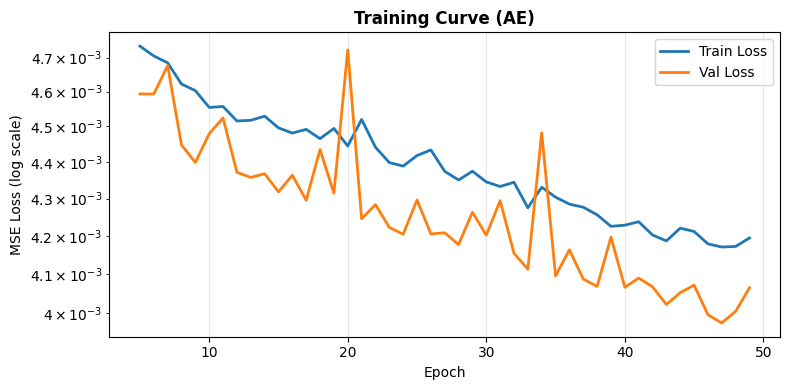

Saved training curve: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE\AE_12dim_0003_ReLU_more_layers\loss_curve.png


In [9]:
resume_state_dict = None
resume_initial_val = None
resume_source_path = None
# Resume logic: load checkpoint, check compatibility, extract state dict and initial val loss if available
if RESUME_TRAINING:
    if RESUME_MODEL_PATH is None:
        raise ValueError('RESUME_TRAINING=True but RESUME_MODEL_PATH is None.')

    resume_source_path = Path(RESUME_MODEL_PATH)
    if not resume_source_path.is_absolute():
        if IS_COLAB:
            resume_source_path = Path('/content/drive/MyDrive') / resume_source_path
        else:
            resume_source_path = project_root / resume_source_path
    resume_source_path = resume_source_path.resolve()

    if not resume_source_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {resume_source_path}')

    checkpoint = torch.load(resume_source_path, map_location=device)
    state_dict = checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint

    probe_model = AutoEncoder(input_dim=x_train.shape[1], latent_dim=LATENT_DIM, hidden_dims=HIDDEN_DIMS)
    current_shapes = {k: tuple(v.shape) for k, v in probe_model.state_dict().items()}
    loaded_shapes = {k: tuple(v.shape) for k, v in state_dict.items()}

    missing_keys = [k for k in current_shapes.keys() if k not in loaded_shapes]
    shape_mismatches = [
        (k, loaded_shapes[k], current_shapes[k])
        for k in current_shapes.keys()
        if k in loaded_shapes and loaded_shapes[k] != current_shapes[k]
    ]

    if missing_keys or shape_mismatches:
        suggested_hidden = []
        # Cerchiamo tutti i pesi dei layer lineari nell'encoder
        for key, weight in state_dict.items():
            if key.startswith('encoder.') and key.endswith('.weight'):
                # Escludiamo il primo strato (input_dim -> hidden[0])
                # Se il peso ha come input input_dim, è il primo layer, lo saltiamo
                if weight.shape[1] == x_train.shape[1]:
                    continue
                suggested_hidden.append(int(weight.shape[0]))

        # L'ultimo elemento trovato sarà il latent_dim
        if suggested_hidden:
            ckpt_latent_dim = suggested_hidden[-1]
            ckpt_hidden_dims = suggested_hidden[:-1]
            hint = (
                f'Checkpoint expects latent_dim={ckpt_latent_dim}, '
                f'hidden_dims={ckpt_hidden_dims}. '
                'Set these values to match before resuming, or start a new run without resume.'
            )
        else:
            hint = 'Checkpoint architecture could not be inferred. Use a checkpoint saved with the same model architecture.'

        details = []
        if missing_keys:
            details.append(f'Missing keys (first 5): {missing_keys[:5]}')
        if shape_mismatches:
            k, loaded_shape, current_shape = shape_mismatches[0]
            details.append(f'Shape mismatch example: {k} loaded={loaded_shape}, current={current_shape}')

        raise RuntimeError(
            'Incompatible checkpoint for current AutoEncoder architecture. ' + hint + (' | ' + ' ; '.join(details) if details else '')
        )

    resume_state_dict = state_dict
    if isinstance(checkpoint, dict) and 'best_val_loss' in checkpoint:
        resume_initial_val = float(checkpoint['best_val_loss'])

    if resume_initial_val is None:
        temp_model = AutoEncoder(input_dim=x_train.shape[1], latent_dim=LATENT_DIM, hidden_dims=HIDDEN_DIMS).to(device)
        temp_model.load_state_dict(resume_state_dict)
        temp_model.eval()

        val_loader = DataLoader(TensorDataset(x_val), batch_size=BATCH_SIZE, shuffle=False)
        criterion = nn.MSELoss()
        val_loss_sum = 0.0
        with torch.no_grad():
            for (xb,) in val_loader:
                xb = xb.to(device)
                pred = temp_model(xb)
                loss = criterion(pred, xb)
                val_loss_sum += loss.item() * xb.size(0)
        resume_initial_val = val_loss_sum / len(val_loader.dataset)

    print(f'Loaded checkpoint: {resume_source_path}')
    print(f'Checkpoint validation MSE (baseline for resume): {resume_initial_val:.6f}')






# Train the model (or resume training if applicable)
model, history, best_val = train_AE(
    x_train_tensor=x_train,
    x_val_tensor=x_val,
    latent_dim=LATENT_DIM,
    hidden_dims=HIDDEN_DIMS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    dropout=DROPOUT,
    seed=SEED,
    scheduler_name=SCHEDULER_NAME,
    cosine_t_max=COSINE_T_MAX,
    cosine_eta_min=COSINE_ETA_MIN,
    resume_state_dict=resume_state_dict,
    initial_best_val=resume_initial_val,
 )


best_model_path = run_output_dir / 'best_model.pt'
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'model_config': {
            'input_dim': int(x_train.shape[1]),
            'latent_dim': int(LATENT_DIM),
            'hidden_dims': HIDDEN_DIMS,
            'epochs': int(EPOCHS),
            'batch_size': int(BATCH_SIZE),
            'lr': float(LR),
            'weight_decay': float(WEIGHT_DECAY),
            'seed': int(SEED),
            'scheduler': {
                'key': str(SCHEDULER_NAME).strip().lower(),
            },
        },
        'best_val_loss': float(best_val),
    },
    best_model_path,
 )
print(f'Saved best model: {best_model_path}')
print(f'Best validation loss: {best_val:.6f}')


fig, ax = plt.subplots(figsize=(8, 4))
epochs_to_plot = list(range(5, EPOCHS))
ax.plot(epochs_to_plot, history['train_loss'][5:], label='Train Loss', linewidth=2)
ax.plot(epochs_to_plot, history['val_loss'][5:], label='Val Loss', linewidth=2)
ax.set_title('Training Curve (AE)', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_yscale('log')
ax.set_ylabel('MSE Loss (log scale)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()

train_curve_path = run_output_dir / 'loss_curve.png'
fig.savefig(train_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved training curve: {train_curve_path}')


In [10]:
print(model)

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=131044, out_features=4096, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.02, inplace=False)
    (3): Linear(in_features=4096, out_features=2048, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.02, inplace=False)
    (6): Linear(in_features=2048, out_features=1024, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.02, inplace=False)
    (9): Linear(in_features=1024, out_features=512, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.02, inplace=False)
    (12): Linear(in_features=512, out_features=12, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.02, inplace=False)
    (3): Linear(in_features=512, out_features=1024, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.02, inplace=False)
    (6): Linear(in_features=1024, out_features=2048, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.02, inplace=False)
    (9): Linear(in_features=2048

## Step 6: Matrix-Level Reconstruction Visualization
Show the same reconstruction plots used in the PCA notebook: clustered heatmaps and standard heatmaps (original, reconstructed, error).

Original Matrix:
[[1.     0.3398 0.3781 0.309  0.5604]
 [0.3398 1.     0.2909 0.5142 0.4363]
 [0.3781 0.2909 1.     0.2982 0.3681]
 [0.309  0.5142 0.2982 1.     0.4061]
 [0.5604 0.4363 0.3681 0.4061 1.    ]]
Reconstructed Matrix:
[[0.9835 0.3459 0.3712 0.3231 0.5485]
 [0.351  0.9922 0.2701 0.5198 0.4379]
 [0.3693 0.2736 0.9905 0.3055 0.3536]
 [0.3212 0.5218 0.3038 0.9793 0.4073]
 [0.     0.4361 0.352  0.4091 0.9816]]
Error Matrix:
[[-0.0165  0.0062 -0.0069  0.0142 -0.0119]
 [ 0.0112 -0.0078 -0.0208  0.0056  0.0016]
 [-0.0088 -0.0173 -0.0095  0.0073 -0.0145]
 [ 0.0123  0.0076  0.0055 -0.0207  0.0013]
 [-0.5604 -0.0002 -0.0161  0.003  -0.0184]]
Sample index: 0
MSE: 0.005935 | MAE: 0.021820 | Frobenius: 27.887318
Error range - Min: -1.000000 | Max: 0.184424


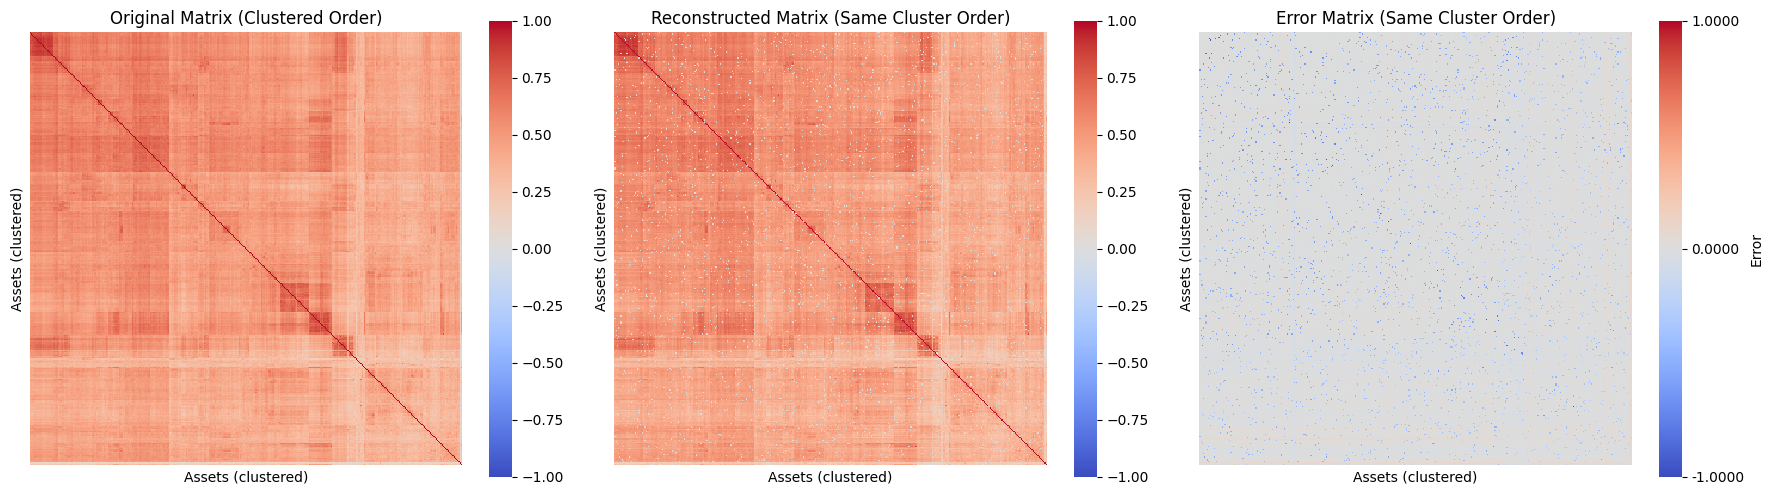

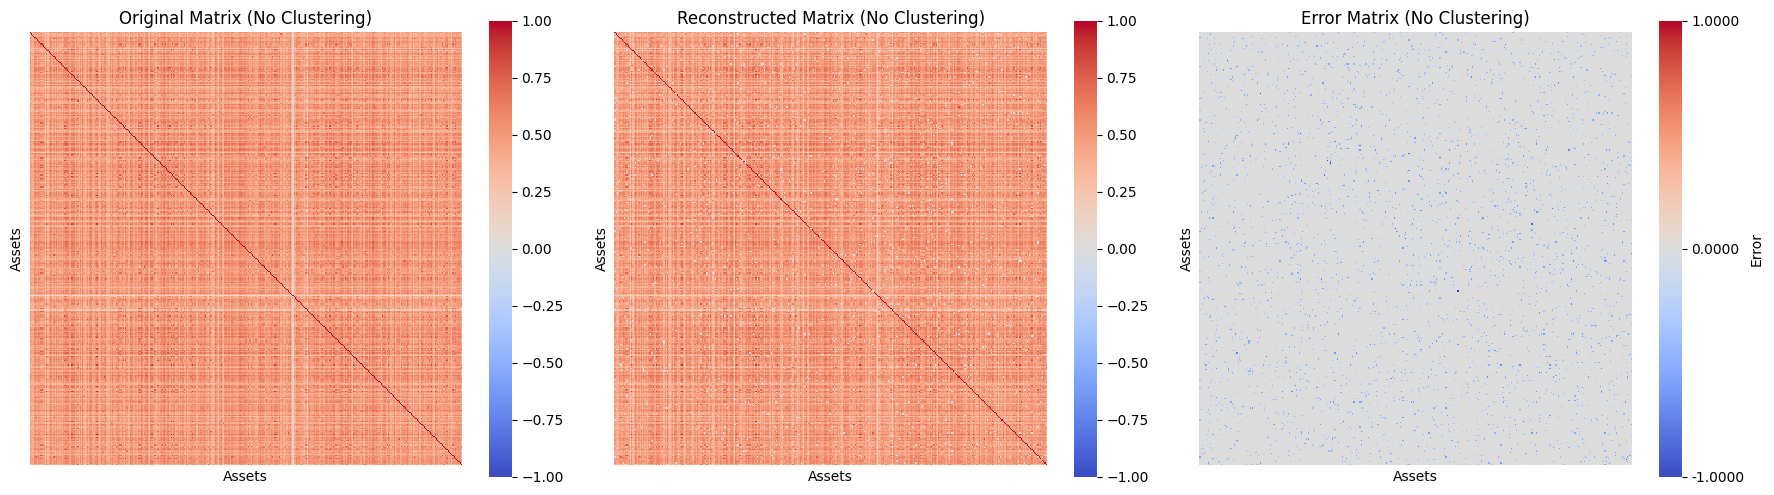

Saved heatmaps for matrix index 0:
 - C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE\AE_12dim_0003_ReLU_more_layers\heatmaps\idx0\clustered_heatmaps.png
 - C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE\AE_12dim_0003_ReLU_more_layers\heatmaps\idx0\standard_heatmaps.png


In [11]:
recon_corr = reconstruct_matrices(model, x_test, n_assets=n_assets)

SAMPLE_IDX = 0

if not (0 <= SAMPLE_IDX < test_np.shape[0]):
    raise ValueError(f'SAMPLE_IDX must be in [0, {test_np.shape[0] - 1}]')

orig_mat = test_np[SAMPLE_IDX]
recon_mat = recon_corr[SAMPLE_IDX]
err_mat = recon_mat - orig_mat

print(f"Original Matrix:\n{orig_mat[:5, :5]}")  # Print the top-left 5x5 block of the original matrix for inspection
print(f"Reconstructed Matrix:\n{recon_mat[:5, :5]}")  # Print the top-left 5x5 block of the reconstructed matrix for inspection
print(f"Error Matrix:\n{err_mat[:5, :5]}")  # Print the top-left 5x5 block of the error matrix for inspection

mse_sample = float(np.mean((recon_mat - orig_mat) ** 2))
mae_sample = float(np.mean(np.abs(recon_mat - orig_mat)))
fro_sample = float(np.linalg.norm(recon_mat - orig_mat, ord='fro'))

print(f'Sample index: {SAMPLE_IDX}')
print(f'MSE: {mse_sample:.6f} | MAE: {mae_sample:.6f} | Frobenius: {fro_sample:.6f}')
print(f'Error range - Min: {err_mat.min():.6f} | Max: {err_mat.max():.6f}')

heatmap_base_dir = run_output_dir / 'heatmaps'
heatmap_base_dir.mkdir(parents=True, exist_ok=True)
heatmap_dir = heatmap_base_dir / f'idx{SAMPLE_IDX}'
heatmap_dir.mkdir(parents=True, exist_ok=True)

shared_cmap = 'coolwarm'
err_abs_max = float(np.max(np.abs(err_mat)))
if err_abs_max == 0:
    err_abs_max = 1e-6

# Build a single cluster ordering from the original matrix and reuse it for all three panels.
cluster_ref = sns.clustermap(
    orig_mat,
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
row_order = cluster_ref.dendrogram_row.reordered_ind
col_order = cluster_ref.dendrogram_col.reordered_ind
plt.close(cluster_ref.fig)

orig_mat_clustered = orig_mat[np.ix_(row_order, col_order)]
recon_mat_clustered = recon_mat[np.ix_(row_order, col_order)]
err_mat_clustered = err_mat[np.ix_(row_order, col_order)]

fig_cluster, axes_cluster = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    orig_mat_clustered,
    ax=axes_cluster[0],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
)
axes_cluster[0].set_title('Original Matrix (Clustered Order)')

sns.heatmap(
    recon_mat_clustered,
    ax=axes_cluster[1],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
)
axes_cluster[1].set_title('Reconstructed Matrix (Same Cluster Order)')

hm_cluster_err = sns.heatmap(
    err_mat_clustered,
    ax=axes_cluster[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes_cluster[2].set_title('Error Matrix (Same Cluster Order)')

cbar_cluster = hm_cluster_err.collections[0].colorbar
cbar_cluster.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_cluster.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes_cluster:
    ax.set_xlabel('Assets (clustered)')
    ax.set_ylabel('Assets (clustered)')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path_cluster_all = heatmap_dir / 'clustered_heatmaps.png'
fig_cluster.savefig(path_cluster_all, dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_mat, ax=axes[0], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[0].set_title('Original Matrix (No Clustering)')

sns.heatmap(recon_mat, ax=axes[1], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[1].set_title('Reconstructed Matrix (No Clustering)')

hm = sns.heatmap(
    err_mat,
    ax=axes[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes[2].set_title('Error Matrix (No Clustering)')

cbar_std = hm.collections[0].colorbar
cbar_std.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_std.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes:
    ax.set_xlabel('Assets')
    ax.set_ylabel('Assets')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path_standard = heatmap_dir / 'standard_heatmaps.png'
fig.savefig(path_standard, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved heatmaps for matrix index {SAMPLE_IDX}:')
print(f' - {path_cluster_all}')
print(f' - {path_standard}')

## Step 7: Reconstruction Error Statistics
Compute error statistics on the test set (MSE, MAE, Frobenius norm).

In [12]:
# Compute error statistics on test set only
recon_corr_test = recon_corr

errors_df, errors_stats = reconstruction_errors(test_np, recon_corr_test)

print('Reconstruction error statistics (Test Set):')
display(errors_stats)

Reconstruction error statistics (Test Set):


,mean,std,min,median,max
MSE,0.004026,0.001536,0.001786,0.003202,0.006662
MAE,0.023619,0.003529,0.017935,0.023381,0.030214
Frobenius,22.565895,4.332138,15.300453,20.485344,29.547770


In [13]:
results_path = run_output_dir / 'run_results.json'

recon_stats_payload = None
if 'errors_stats' in globals():
    recon_stats_payload = errors_stats.astype(float).to_dict()

scheduler_key = str(SCHEDULER_NAME).strip().lower()

if scheduler_key == 'none':
    scheduler_payload = None
elif scheduler_key == 'cosine':
    scheduler_payload = {
        'key': scheduler_key,
        'T_max': int(COSINE_T_MAX),
        'eta_min': float(COSINE_ETA_MIN),
    }

resumed = bool(RESUME_TRAINING)
if resumed:
    resume_info = {
        'source_model_path': str(resume_source_path) if resume_source_path is not None else None,
        'initial_best_val': float(resume_initial_val) if resume_initial_val is not None else None,
    }
else:
    resume_info = None

if MODEL_TYPE == 'linearAE':
    dropout_info = None
    hidden_dims_info = None
elif MODEL_TYPE == "AE":
    dropout_info = float(DROPOUT)
    hidden_dims_info = [int(x) for x in HIDDEN_DIMS]

results_payload = {
    'run': RUN,
    'seed': int(SEED),
    'dataset_info': {
        'dataset_name': DATASET_NAME,
        'n_matrices': int(n_matrices),
        'n_assets': int(n_assets),
        'n_features': int(n_features),
        'splits': {
            'train_size': int(n_train),
            'val_size': int(n_val),
            'test_size': int(n_test),
            'val_fraction': round(float(VAL_FRACTION), 2),
            'test_fraction': round(float(TEST_FRACTION), 2),
        },
    },
    'model': {
        'model_type': MODEL_TYPE,
        'latent_dim': int(LATENT_DIM),
        'hidden_dims': hidden_dims_info,
        'epochs': int(EPOCHS),
        'batch_size': int(BATCH_SIZE),
        'lr': float(LR),
        'weight_decay': float(WEIGHT_DECAY),
        'dropout': dropout_info,
        'scheduler': scheduler_payload,
        'best_val_loss': float(best_val) if 'best_val' in globals() else None,
        'resume': resume_info,
    },
    'artifacts': {
        'best_model_path': str(best_model_path) if 'best_model_path' in globals() else None,
        'training_curve_path': str(train_curve_path) if 'train_curve_path' in globals() else None,
    },
    'metrics': {
        'reconstruction_stats_on_test_set': recon_stats_payload,
    },
    'loss_history': {
        'train_loss': [float(x) for x in history['train_loss']],
        'val_loss': [float(x) for x in history['val_loss']],
        'lr': [float(x) for x in history['lr']] if 'lr' in history else None,
    },
}

with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results_payload, f, indent=4)

print(f'Saved results: {results_path}')

Saved results: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\AE\AE_12dim_0003_ReLU_more_layers\run_results.json
